In [42]:
#必要なモジュールのインポート
import boto3 # AWSのサービスを利用するときに必須
import json # json形式のデータを処理する
from PIL import Image # pillow の Image モジュール 画像処理に使用する

In [43]:
# コレクションIDを入力
collection_id = 'MyCollection'

# サービスクライアントを作成

In [44]:
rekognition = boto3.client('rekognition')

# コレクションの作成

In [54]:
# コレクションを作成する
result = rekognition.create_collection(CollectionId=collection_id)

# 結果のjsonを整形して表示
print(json.dumps(result, indent=4))

{
    "StatusCode": 200,
    "CollectionArn": "aws:rekognition:us-east-1:422191043663:collection/MyCollection",
    "FaceModelVersion": "7.0",
    "ResponseMetadata": {
        "RequestId": "60ebec99-480d-4ff5-8f83-2029badc56e8",
        "HTTPStatusCode": 200,
        "HTTPHeaders": {
            "x-amzn-requestid": "60ebec99-480d-4ff5-8f83-2029badc56e8",
            "content-type": "application/x-amz-json-1.1",
            "content-length": "124",
            "date": "Wed, 19 Feb 2025 05:38:28 GMT"
        },
        "RetryAttempts": 0
    }
}


# コレクションの表示

In [59]:
print('コレクションの一覧')
# コレクションの一覧を取得
result = rekognition.list_collections()

# 結果のjsonを整形して表示
print(json.dumps(result, indent=4))

print('登録されている顔の一覧')
# 登録された顔の一覧を取得
result = rekognition.list_faces(CollectionId=collection_id)
# 登録された顔の一覧を表示
print(json.dumps(result, indent=4))

コレクションの一覧
{
    "CollectionIds": [
        "MyCollection"
    ],
    "FaceModelVersions": [
        "7.0"
    ],
    "ResponseMetadata": {
        "RequestId": "e0a064c3-048a-41c7-98f0-6050667da390",
        "HTTPStatusCode": 200,
        "HTTPHeaders": {
            "x-amzn-requestid": "e0a064c3-048a-41c7-98f0-6050667da390",
            "content-type": "application/x-amz-json-1.1",
            "content-length": "62",
            "date": "Wed, 19 Feb 2025 05:40:38 GMT"
        },
        "RetryAttempts": 0
    }
}
登録されている顔の一覧
{
    "Faces": [
        {
            "FaceId": "0d4fcba2-0c2e-4791-9348-1602ba2e3742",
            "BoundingBox": {
                "Width": 0.15887799859046936,
                "Height": 0.10068999975919724,
                "Left": 0.33444300293922424,
                "Top": 0.27755001187324524
            },
            "ImageId": "ede767b8-49bb-3d8d-98e1-1060879597ff",
            "Confidence": 99.99200439453125,
            "IndexFacesModelVersion": "7.0"
  

# コレクションに顔を登録する

In [56]:
# 登録する画像のリスト
images_regist = ['mum.jpg', 'target.jpg']

In [58]:
# 顔の登録
print('index_faces:')

# 指定された画像ファイルの分だけ繰り返す
for path in images_regist:
    # 画像ファイルをオープン
    with open(path, 'rb') as file:
        # 画像内の顔を登録
        result = rekognition.index_faces(
            CollectionId=collection_id,
            Image={'Bytes': file.read()})

    # 顔の登録結果を表示
    print(json.dumps(result, indent=4))

index_faces:
{
    "FaceRecords": [
        {
            "Face": {
                "FaceId": "93b591e7-c667-48cb-a4f5-7551992b9aea",
                "BoundingBox": {
                    "Width": 0.3483645021915436,
                    "Height": 0.35312092304229736,
                    "Left": 0.30951350927352905,
                    "Top": 0.11020112037658691
                },
                "ImageId": "72712c2e-f753-3201-8493-a39ed9a125ad",
                "Confidence": 99.99433898925781
            },
            "FaceDetail": {
                "BoundingBox": {
                    "Width": 0.3483645021915436,
                    "Height": 0.35312092304229736,
                    "Left": 0.30951350927352905,
                    "Top": 0.11020112037658691
                },
                "Landmarks": [
                    {
                        "Type": "eyeLeft",
                        "X": 0.3591139614582062,
                        "Y": 0.26825040578842163
                  

# 画像に写っている顔が、コレクションの中に存在するかをチェック

In [49]:
file_in = 'target.jpg' # コレクションに存在するかチェックする画像
file_out = 'detected.jpg' # 見つかった顔の部分だけを出力する画像ファイル名

In [61]:
# 画像ファイルを開く
with open(file_in, 'rb') as file:
    # 画像内の顔をコレクションから探す
    result = rekognition.search_faces_by_image(
        CollectionId=collection_id,
        Image={'Bytes': file.read()})
# 結果を整形して表示
print(json.dumps(result, indent=4))

{
    "SearchedFaceBoundingBox": {
        "Width": 0.15887810289859772,
        "Height": 0.10069029033184052,
        "Left": 0.33444342017173767,
        "Top": 0.2775495648384094
    },
    "SearchedFaceConfidence": 99.9919662475586,
    "FaceMatches": [
        {
            "Similarity": 100.0,
            "Face": {
                "FaceId": "0d4fcba2-0c2e-4791-9348-1602ba2e3742",
                "BoundingBox": {
                    "Width": 0.15887799859046936,
                    "Height": 0.10068999975919724,
                    "Left": 0.33444300293922424,
                    "Top": 0.27755001187324524
                },
                "ImageId": "ede767b8-49bb-3d8d-98e1-1060879597ff",
                "Confidence": 99.99200439453125,
                "IndexFacesModelVersion": "7.0"
            }
        },
        {
            "Similarity": 99.90725708007812,
            "Face": {
                "FaceId": "93b591e7-c667-48cb-a4f5-7551992b9aea",
                "BoundingBox"

## 見つかった顔の部分だけの画像を作る

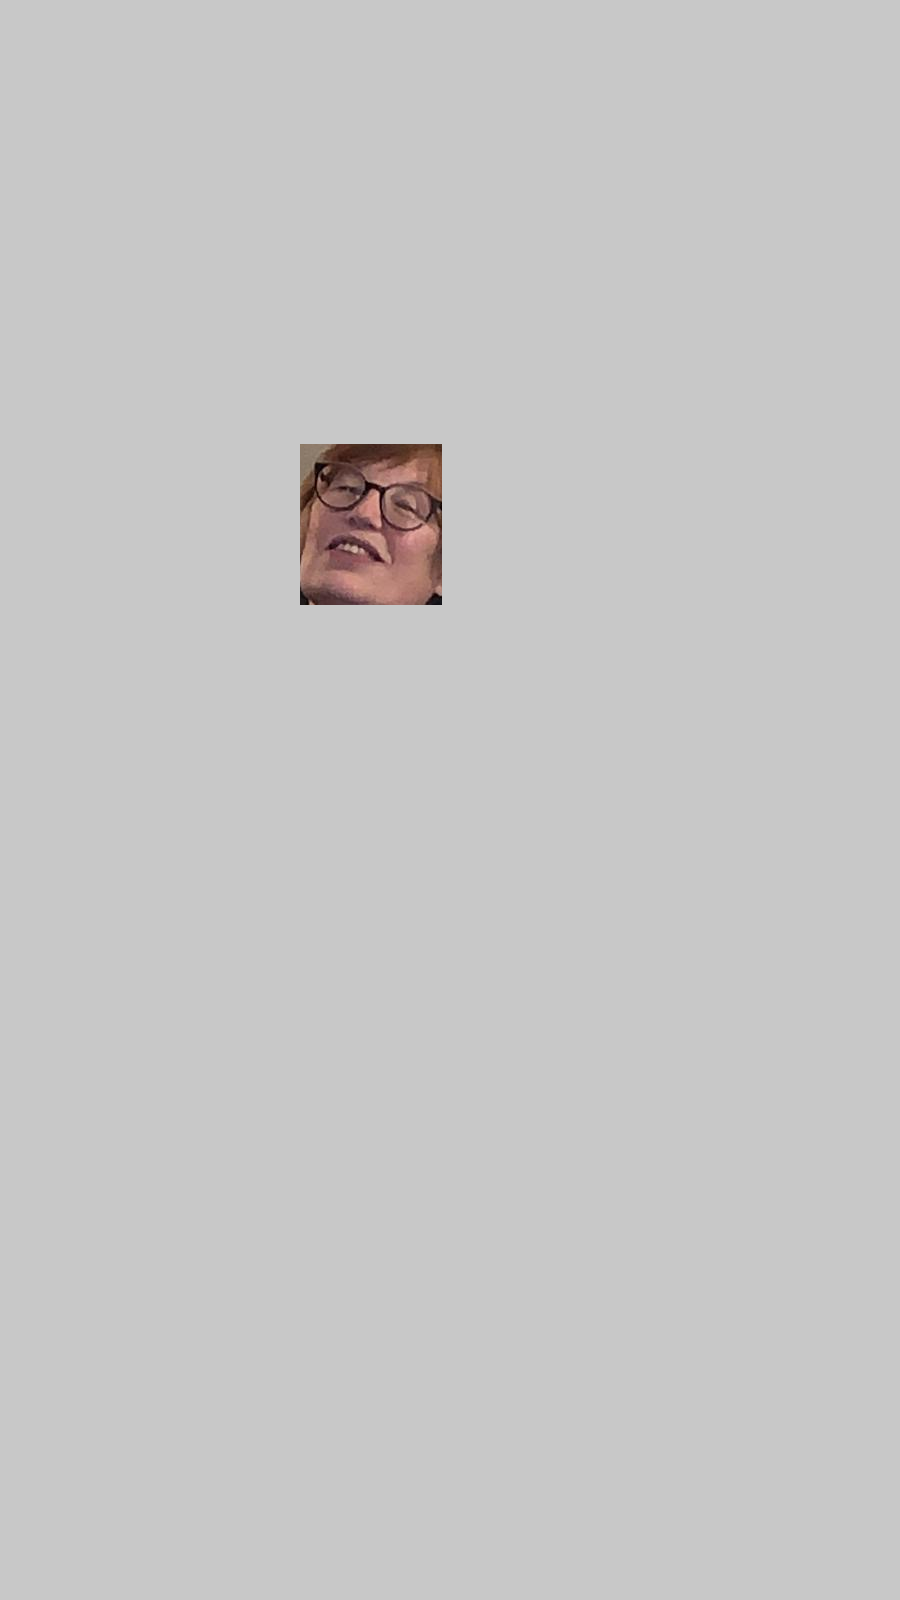

In [51]:
# 入力画像のファイルを読み込む
image_in = Image.open(file_in)

# 画像サイズを取得
w, h = image_in.size

# Imageオブジェクトを生成
image_out = Image.new('RGB', (w, h), (200, 200, 200))

# 顔がコレクションに登録されている場合
if result['FaceMatches']:
    # バウンディングボックスを取得
    box = result['SearchedFaceBoundingBox']
    # 顔の左、上、右、下の座標を取得
    left = int(box['Left']*w)
    top = int(box['Top']*h)
    right = left+int(box['Width']*w)
    bottom = top+int(box['Height']*h)

    # 入力画像から出力画像に顔の部分を貼り付け
    image_out.paste(
        image_in.crop((left, top, right, bottom)),
        (left, top))

# 画像を保存
image_out.save(file_out)
# 画像を表示
image_out.show()

# コレクションの削除

In [52]:
result = rekognition.delete_collection(CollectionId=collection_id)
print(json.dumps(result, indent=4))

{
    "StatusCode": 200,
    "ResponseMetadata": {
        "RequestId": "0f32adaf-14e7-403b-bbb9-4f59d6dff2e3",
        "HTTPStatusCode": 200,
        "HTTPHeaders": {
            "x-amzn-requestid": "0f32adaf-14e7-403b-bbb9-4f59d6dff2e3",
            "content-type": "application/x-amz-json-1.1",
            "content-length": "18",
            "date": "Wed, 19 Feb 2025 05:18:27 GMT"
        },
        "RetryAttempts": 0
    }
}
